<a href="https://colab.research.google.com/github/ShlokVaibhav/AI_for_Analog_Design/blob/spec_implementation/Analog_Specs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# In this file, a 2 stage op-amp is simulated online using NGSpice
In next 3 cells, we are just installing the required modules and files

In [1]:
%%capture
! python --version  # Pyspice works with python  3.9 or lower
!pip install -q gdown

In [2]:
%%capture
!gdown --id 1NJs6nJIQN3fsmf7IJ9yrPfo0g2SwTpeC -O params.inc;
!gdown --id 1tKXE0thOO_R2apoPKUVW6FFMPkYw9qIp -O schematic.spice;

In [3]:
%%capture
!pip install matplotlib
!pip install numpy
!pip install scipy

In [4]:
%%capture
import sys
import subprocess
import platform

def install_ngspice():
    system = platform.system()
    if system == "Linux":
        # Google Colab
        subprocess.run(["apt-get", "update"], check=True)
        subprocess.run(["apt-get", "-y", "install", "ngspice"], check=True)

    elif system == "Windows":
        # Conda-based Windows
        subprocess.run(
            ["conda", "install", "-y", "-c", "conda-forge", "ngspice"],
            shell=True
        )
    else:
        raise RuntimeError("Unsupported OS")

install_ngspice()


# The schematic to be simulated is
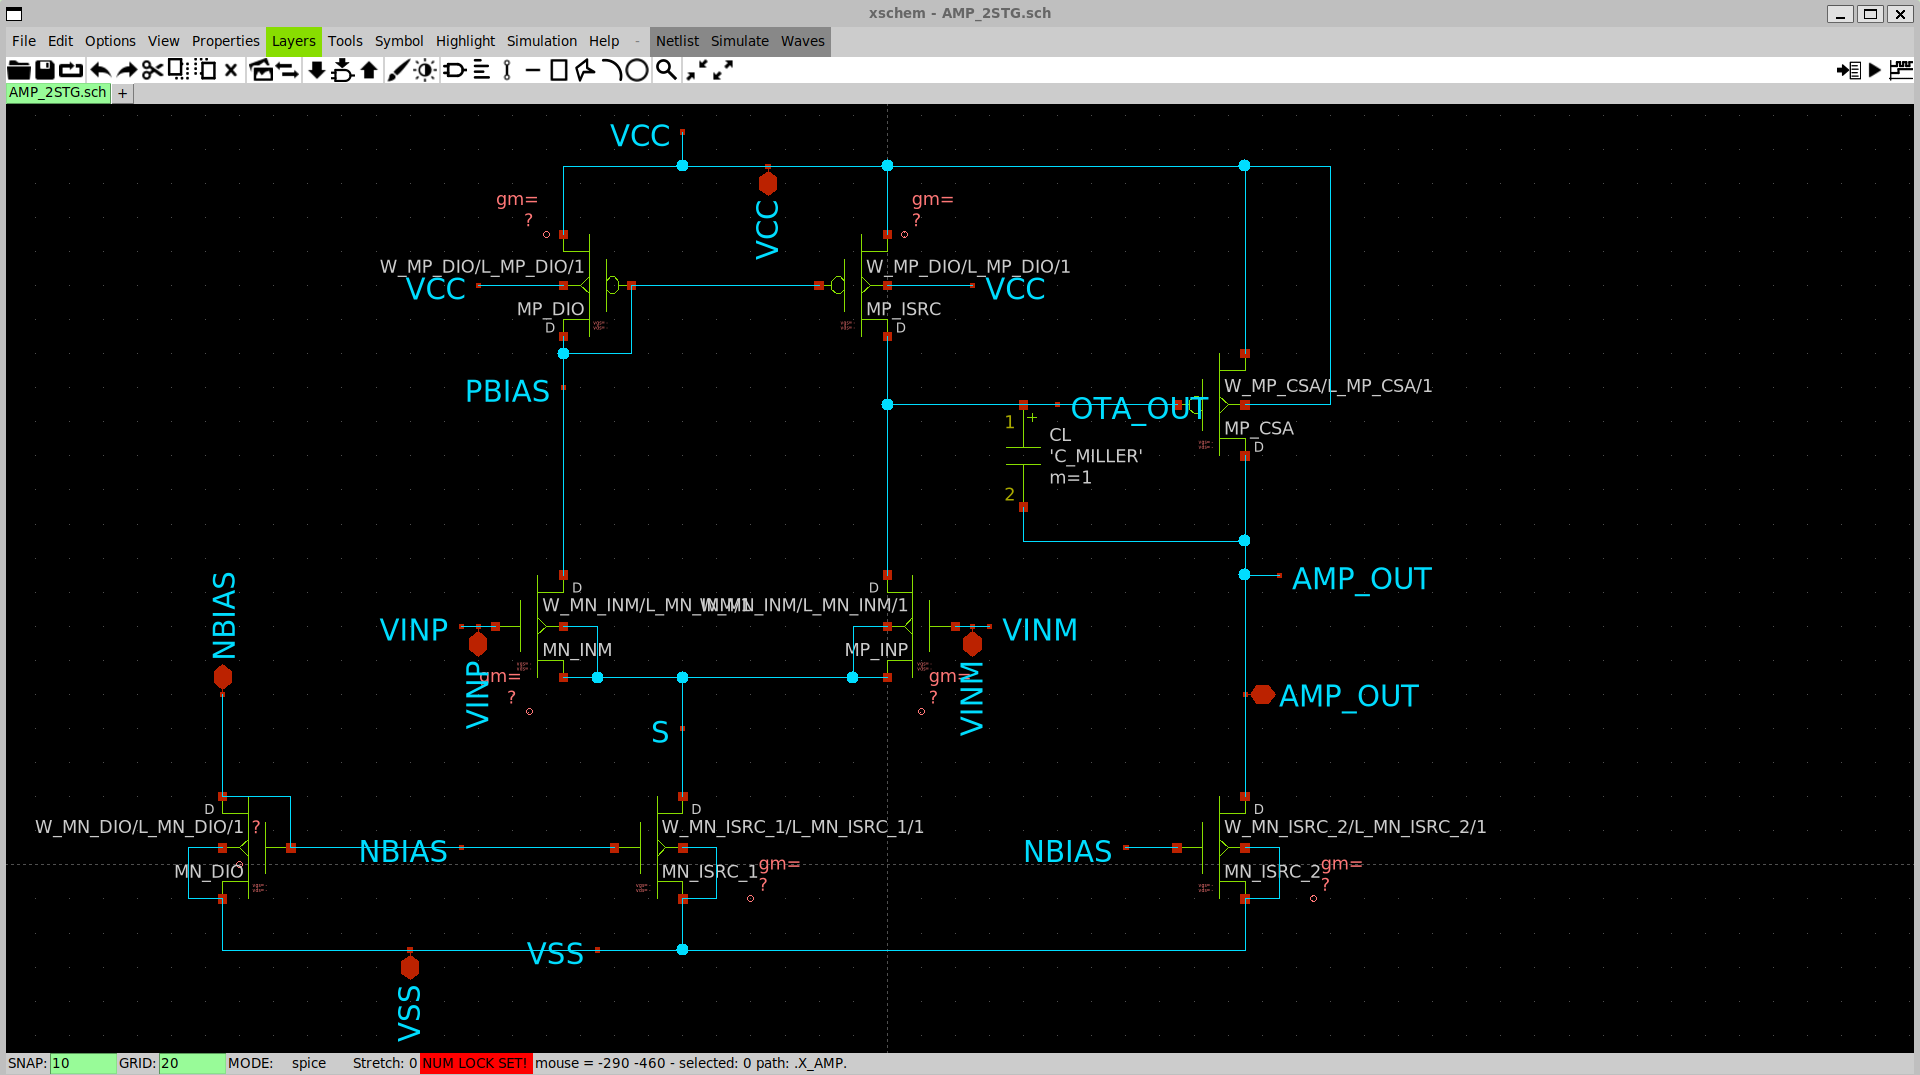


# The testbench now being simulated is :
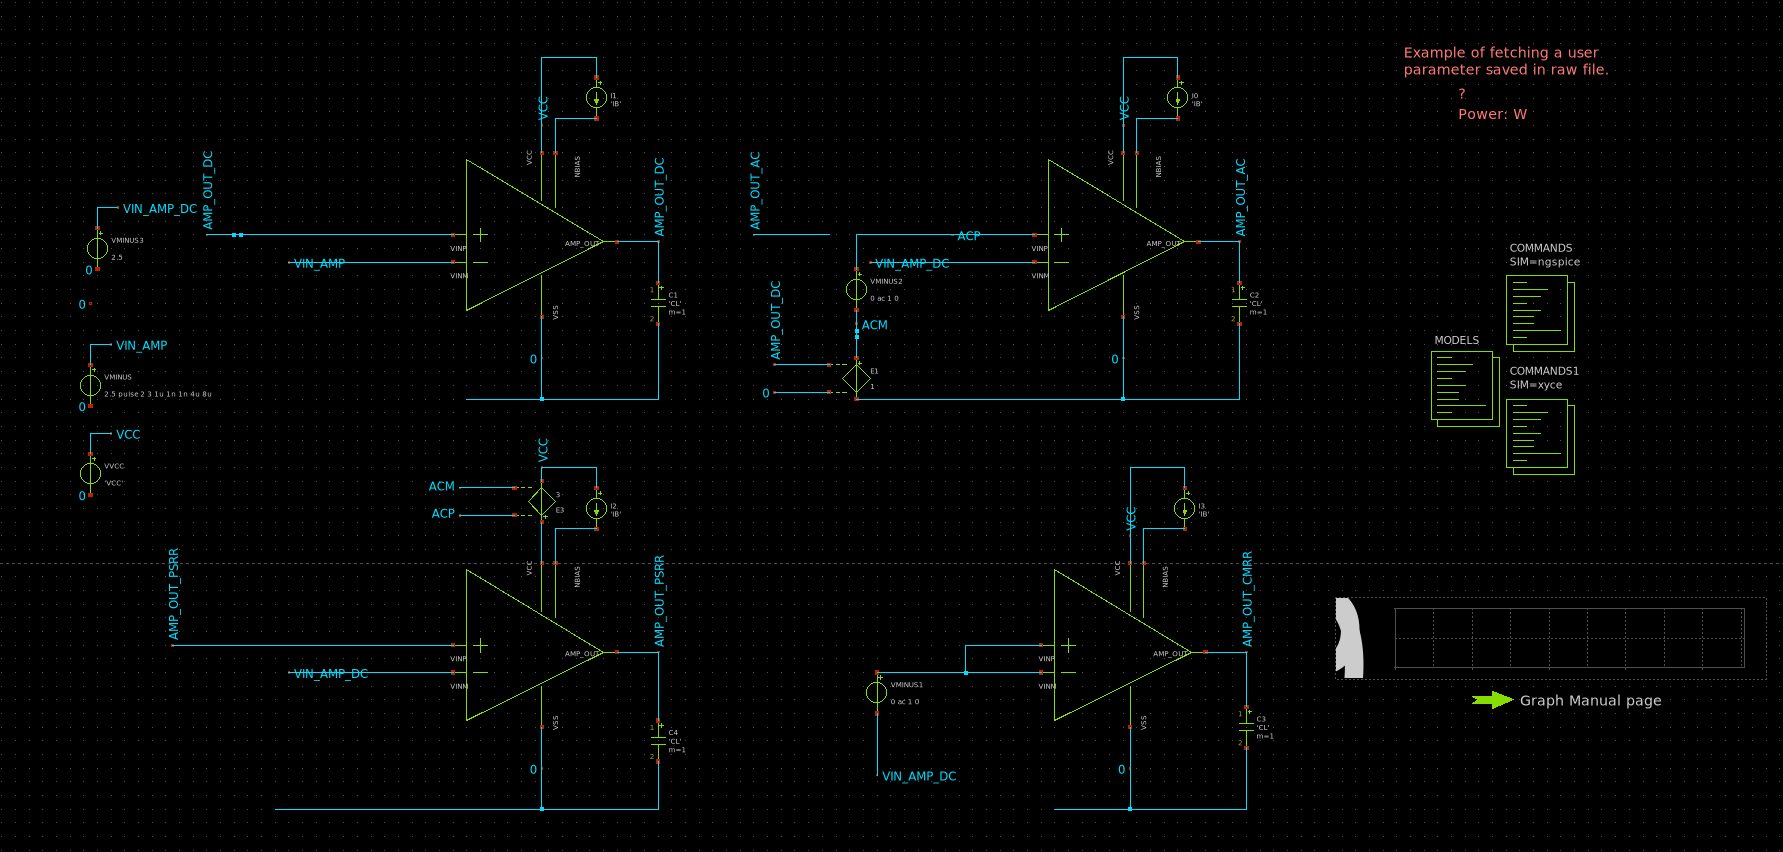

In [5]:
%%capture
subprocess.call("ngspice -b -o output.log test_ac.spice", shell=True)

Power: 0.236781084mW
Output swing (VCC=5V): 4.52387492V
DC PSRR is: 170.62977039999998dB
DC CMRR is: 139.9081498dB
DC Gain is: 89.3113565dB
UGB is: 14.08MHz
PM is: -13.15°


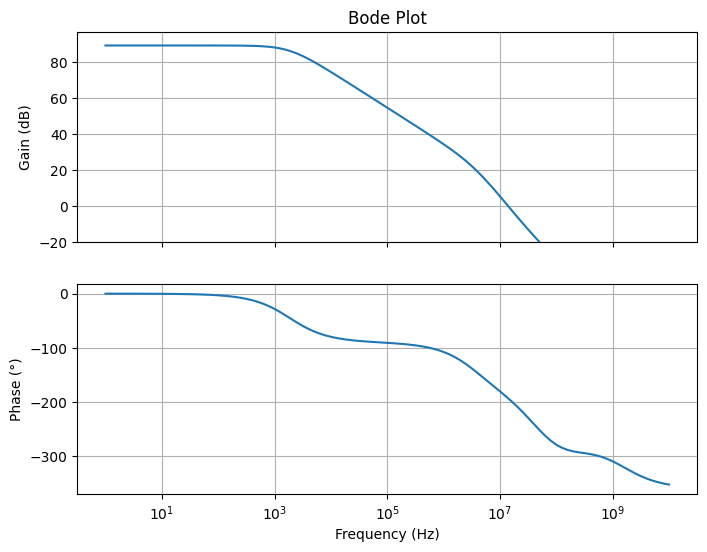

In [21]:
import numpy as np
import matplotlib.pyplot as plt
# Analog specs
def Power():  # returns the power in mW
    with open("power.dat", "r") as f:
      power = 1000*float(f.read().split(' ')[-2])
    f.close()
    return power

def out_swing():  # returns the output swing
    with open("margin.dat", "r") as f:
      out_swing = float(f.read().split(' ')[-2])
    f.close()
    return out_swing

def PSRR():
    PSRR_data = np.loadtxt("PSRR.dat")
    ADC, _,_ = DC_gain()
    return -PSRR_data[0, 1] + ADC

def CMRR():
    CMRR_data = np.loadtxt("CMRR.dat")
    ADC,_,_ = DC_gain()
    return -CMRR_data[0, 1] + ADC

def DC_gain(show=0):
    AC_data = np.loadtxt("AC.dat")
    freq  = AC_data[:, 0]
    gain  = AC_data[:, 1]
    phase = AC_data[:, 3]*180/np.pi - 180
    sign_change_idx = np.where(np.diff(np.sign(gain)) != 0)[0]

    i = sign_change_idx[0]  # first crossover

    # Step 2: Linear interpolation for accurate crossover frequency
    f1, f2 = freq[i], freq[i+1]
    g1, g2 = gain[i], gain[i+1]

    # frequency where gain = 0 dB
    f_gc = f1 + (0 - g1) * (f2 - f1) / (g2 - g1)

    # Step 3: interpolate phase at gain crossover
    p1, p2 = phase[i], phase[i+1]
    phase_gc = p1 + (0 - g1) * (p2 - p1) / (g2 - g1)+180

    if show==1:
      fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 6))

      # Magnitude plot
      ax1.semilogx(freq, gain)
      ax1.set_ylabel("Gain (dB)")
      ax1.grid(True, which="both")
      ax1.set_title("Bode Plot")
      ax1.set_ylim(bottom=-20)

      # Phase plot
      ax2.semilogx(freq, phase)
      ax2.set_xlabel("Frequency (Hz)")
      ax2.set_ylabel("Phase (°)")
      ax2.grid(True, which="both")

      plt.show()
      return
    return gain[0], f_gc/1e6, phase_gc


print("Power: " + str(Power())+"mW")
print("Output swing (VCC=5V): " + str(out_swing())+"V")
print("DC PSRR is: " + str(PSRR())+"dB")
print("DC CMRR is: " + str(CMRR())+"dB")
[Adc, UGB, PM] = DC_gain(0)
print("DC Gain is: " + str(Adc)+"dB")
print("UGB is: " + f"{UGB:.4g}"+"MHz")
print("PM is: " +  f"{PM:.4g}"+"°")
DC_gain(1)


In [22]:
#The rise fall time specs can be used to find the slew rate
# returns fall time in ns
def Fall_Time(W):
  data = np.loadtxt('Aus.dat')  # your .dat file
  #data = np.loadtxt('I_SUP.dat')  # your .dat file

  # If your file has two columns
  t = data[:, 0]   # first column
  V = data[:, 1]  # second column

  v_min = V.min()
  v_max = V.max()
  v10 = v_min + 0.1*(v_max - v_min)
  v90 = v_min + 0.9*(v_max - v_min)
  tf10 = t[np.where(V <= v10)[0][0]]  # first time V crosses 10%
  tf90 = t[np.where(V <= v90)[0][0]]  # first time V crosses 90%
  tf = (tf10 - tf90)*1e9
  return tf


# returns rise time in ns
def Rise_Time(W):
  data = np.loadtxt('Aus.dat')  # your .dat file
  #data = np.loadtxt('I_SUP.dat')  # your .dat file

  # If your file has two columns
  t = data[:, 0]   # first column
  V = data[:, 1]  # second column

  v_min = V.min()
  v_max = V.max()
  v10 = v_min + 0.1*(v_max - v_min)
  v90 = v_min + 0.9*(v_max - v_min)
  tr10 = t[np.where((V >= v10) & (t > 3e-9))[0][0]]
  tr90 = t[np.where((V >= v90) & (t > 3e-9))[0][0]]
  tr = (tr90 - tr10)*1e9
  return tr

